### Single Node -  Run time validation

In [67]:
from typing_extensions import TypedDict

class State(TypedDict):
    xyz:str
    abc:str

In [68]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

class OverallState(BaseModel):
    a:str

def node(state:OverallState):
    return {"a": "Hii, I am sai krishna"}

In [69]:
# Build the State Graph

builder = StateGraph(OverallState)
builder.add_node("node",node)
builder.add_edge(START,"node")
builder.add_edge("node",END)
graph = builder.compile()



In [70]:
graph.invoke({"a":"hello"})

{'a': 'Hii, I am sai krishna'}

### Multiple Nodes - Run time validation

In [71]:
from langgraph.graph import StateGraph,START,END
from typing_extensions import TypedDict
from pydantic import BaseModel

class OverallState(BaseModel):
    a: str 

def bad_node(state:OverallState):
    return {
        "a": "Hii, This is sai krishna" # Invalid
    }

def ok_node(state:OverallState):
    return {
        "a": "good bye"
    }

builder = StateGraph(OverallState)
builder.add_node("bad_node",bad_node)
builder.add_node("ok_node",ok_node)
builder.add_edge(START,"bad_node")
builder.add_edge("bad_node","ok_node")
builder.add_edge("ok_node",END)

graph = builder.compile()

graph.invoke({"a":"Hello"})

{'a': 'good bye'}

### Prompt Chaining

Prompt chaining decomposes a task into a sequence of steps, where each LLM call processes the output of the previous one. You can add programmatic checks on any intermediate steps to ensure that the process is still on track.

When to use this workflow: This workflow is ideal for situations where the task can be easily and cleanly decomposed into fixed subtasks. The main goal is to trade off latency for higher accuracy, by making each LLM call an easier task.

![promptchaining](images/prompt-chaining.png)

In [72]:
import os 
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen-2.5-32b")

result = llm.invoke("hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 30, 'total_tokens': 40, 'completion_time': 0.05, 'prompt_time': 0.003666383, 'queue_time': 0.235211948, 'total_time': 0.053666383}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-9d462cce-e543-4bcc-add3-0798c14db44a-0', usage_metadata={'input_tokens': 30, 'output_tokens': 10, 'total_tokens': 40})

In [73]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    topic:str
    joke:str
    improved_joke:str
    final_joke:str 
    

In [74]:
# Nodes

def generate_joke(state:State):
    """ First LLM call to generate the initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke":msg.content}

def check_punchline(state:State):
    """ Gate function to check if the joke has a punchline"""

    if "?" in state["joke"] or "!" in state["joke"]:
        return "Fail"
    
    return "Pass"

def improve_joke(state:State):
    """ Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke":msg.content}

def polish_joke(state:State):
    """ Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to the joke: {state['improved_joke']}")
    return {"final_joke":msg.content}

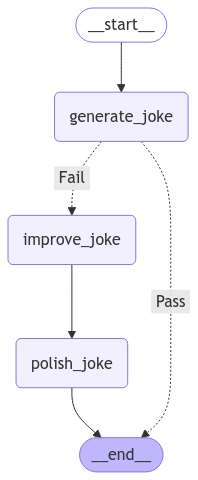

In [75]:
# Build workflow

workflow = StateGraph(State)

#Add nodes
workflow.add_node("generate_joke",generate_joke)
workflow.add_node("improve_joke",improve_joke)
workflow.add_node("polish_joke",polish_joke)

# Add Edges
workflow.add_edge(START,"generate_joke")
workflow.add_conditional_edges("generate_joke",check_punchline,{"Fail":"improve_joke","Pass":END})
workflow.add_edge("improve_joke","polish_joke")
workflow.add_edge("polish_joke",END)

chain = workflow.compile()

display(Image(chain.get_graph().draw_mermaid_png()))



In [76]:
chain.invoke({"topic":"Michal jackson"})

{'topic': 'Michal jackson',
 'joke': 'Why did Michael Jackson refuse to go to the doctor? Because he was afraid of getting a Thriller!',
 'improved_joke': "Why did Michael Jackson refuse to go to the doctor? Because he was afraid the diagnosis would be a real Thriller, and he didn't want to boogie down with bad news!",
 'final_joke': "Why did Michael Jackson refuse to go to the doctor? Because he was afraid the diagnosis would be a real Thriller, and he didn't want to boogie down with bad news! But to his surprise, the doctor just wanted to discuss the latest in Michael's music career, having been a big fan. The real twist? The doctor was actually a time traveler, interested in Michael's impact on future music trends, which included a fusion of his dance moves with advanced robotics."}

### Parallelaization

With parallelization, LLMs work simultaneously on a task:

LLMs can sometimes work simultaneously on a task and have their outputs aggregated programmatically. This workflow, parallelization, manifests in two key variations: Sectioning: Breaking a task into independent subtasks run in parallel. Voting: Running the same task multiple times to get diverse outputs.

When to use this workflow: Parallelization is effective when the divided subtasks can be parallelized for speed, or when multiple perspectives or attempts are needed for higher confidence results. For complex tasks with multiple considerations, LLMs generally perform better when each consideration is handled by a separate LLM call, allowing focused attention on each specific aspect.

![parallelization](images/Parallelization.png)

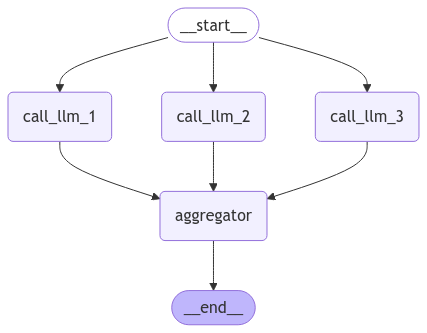

Here is a joke,story and poem about the cats

STORY:
 In a quaint little town nestled between rolling hills and dense forests, there was a charming house that was home to a peculiar family of cats. These weren't just ordinary cats; they were intelligent, whimsical, and each had a unique personality that made them stand out.

The family consisted of four cats: Luna, the eldest and the wisest, with her silvery fur and piercing blue eyes; Leo, the brave and loyal, with his dark fur and a mane of white whiskers; Mia, the curious and adventurous, whose golden fur shone under the sunlight; and finally, there was Paws, the youngest, always ready to play and explore with her fluffy white fur and playful green eyes.

The cats lived in a house that was as magical as they were. The house was full of small cat-sized doors and windows that allowed them to explore every corner of it. The attic was their secret hideout, where they kept their most cherished treasures and played with the old soft toys 

In [77]:
class State(TypedDict):
    topic:str
    joke:str
    story:str
    poem:str 
    combined_output:str

def call_llm_1(state:State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke":msg.content}

def call_llm_2(state:State):
    """Second LLM call to generate Story"""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story":msg.content}

def call_llm_3(state:State):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem":msg.content}

def aggregator(state:State):
    """combine the story,poem,joke into a single output"""
    
    combined = f"Here is a joke,story and poem about the {state['topic']}\n\n"
    combined += f"STORY:\n {state['story']}\n\n"
    combined += f"JOKE: \n {state['joke']}\n\n"
    combined += f"POEM: \n {state['poem']}\n "

    return {"combined_output": combined}


# Build Workflow
parallel_builder = StateGraph(State)

# Add Nodes
parallel_builder.add_node("call_llm_1",call_llm_1)
parallel_builder.add_node("call_llm_2",call_llm_2)
parallel_builder.add_node("call_llm_3",call_llm_3)
parallel_builder.add_node("aggregator",aggregator)

# Add Edges to connect nodes
parallel_builder.add_edge(START,"call_llm_1")
parallel_builder.add_edge(START,"call_llm_2")
parallel_builder.add_edge(START,"call_llm_3")
parallel_builder.add_edge("call_llm_1","aggregator")
parallel_builder.add_edge("call_llm_2","aggregator")
parallel_builder.add_edge("call_llm_3","aggregator")
parallel_builder.add_edge("aggregator",END)

parallel_workflow = parallel_builder.compile()

# show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state_output = parallel_workflow.invoke({"topic":"cats"})
print(state_output["combined_output"])

### Routing

Routing classifies an input and directs it to a specialized followup task. This workflow allows for separation of concerns, and building more specialized prompts. Without this workflow, optimizing for one kind of input can hurt performance on other inputs.

When to use this workflow: Routing works well for complex tasks where there are distinct categories that are better handled separately, and where classification can be handled accurately, either by an LLM or a more traditional classification model/algorithm.

![routing](images/Router.png)

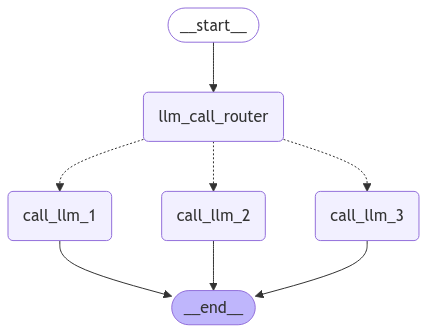

Sure, here’s a cat joke for you:

Why don't cats make good dancers?

Because they have two left feet!


In [78]:
from typing_extensions import Literal
from langchain_core.pydantic_v1 import Field,BaseModel
from langchain_core.messages import SystemMessage,HumanMessage

# schema for structured output to use a routing logic
class Route(BaseModel):
    step: Literal["story","poem","joke"] = Field(
        None, description="The next step in the routing process"
    )

# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

#State
class State(TypedDict):
    input:str
    decision:str
    output:str 

# Nodes
def call_llm_1(state:State):
    """Write a story"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def call_llm_2(state:State):
    """Write a joke"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def call_llm_3(state:State):
    """Write a poem"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state:State):
    """Route the input to appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic

    decision = router.invoke(
        [
            SystemMessage(content = "Route the input to story,joke or poem based on user's request"),
            HumanMessage(content= state["input"])
        ]
    )

    return {"decision":decision.step}

# conditional edge function to route to the appropriate node

def route_decision(state:State):
    # Return the node name which you want to visit next.
    if state["decision"] == "story":
        return "call_llm_1"
    elif state["decision"] == "poem":
        return "call_llm_3"
    elif state["decision"] == "joke":
        return "call_llm_2"

# Build workflow  
route_builder = StateGraph(State)

# Add nodes
route_builder.add_node("call_llm_1",call_llm_1)
route_builder.add_node("call_llm_2",call_llm_2)
route_builder.add_node("call_llm_3",call_llm_3)
route_builder.add_node("llm_call_router",llm_call_router)

# Add edges
route_builder.add_edge(START,"llm_call_router")
route_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "call_llm_1":"call_llm_1",
        "call_llm_2":"call_llm_2",
        "call_llm_3":"call_llm_3"
    }
)
route_builder.add_edge("call_llm_1",END)
route_builder.add_edge("call_llm_2",END)
route_builder.add_edge("call_llm_3",END)

route_workflow = route_builder.compile()

display(Image(route_workflow.get_graph().draw_mermaid_png()))

#Invoke
state = route_workflow.invoke({"input":"write me a joke about cats"})
print(state["output"])

### Orchestrator-Worker

In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

![orchestrator](images/Orchestrator.png)

In [79]:
from typing import Annotated,List
import operator 

class Section(BaseModel):
    name: str = Field(
        description = "Name for the section of the report"
    )
    description: str = Field(
        descripton = "Brief overview of the main topics and concepts to be covered in this section"
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="sections of the report"
    )

planner = llm.with_structured_output(Sections)



### Creating Workers using LangGraph

In [80]:
from langgraph.constants import Send

# Graph State
class State(TypedDict):
    topic:str # Report topic
    sections: List[Section] # List of report sections
    completed_sections : Annotated[list,operator.add] # All workers write to this key in parallel
    final_report: str # Final report

# Worker State
class WorkerState(TypedDict):
    section : Section
    completed_sections : Annotated[list,operator.add]

# Nodes
def Orchestrator(state:State):
    """Orchestrator that generates the plan for report"""
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content = f"Here is the report topic {state["topic"]}")
        ]
    )
    return {"sections":report_sections.sections}

def llm_call(state:WorkerState):
    """Worker writes a section of the report"""

    section = llm.invoke(
        [
            SystemMessage(content="Write the report section following the provided name and description.Include no preamble for each section.use markdown formatting."),
            HumanMessage(content = f"Here is the section name {state['section'].name} and descripton {state['section'].description}")
        ]
    )

    return {"completed_sections": [section.content]}

def synthesizer(state:State):
    """synthesize full report from the sections"""
    completed_sections = state["completed_sections"]

    completed_report_sections = "\n\n-----\n\n".join(completed_sections)
    return {"final_report": completed_report_sections}


def assign_workers(state:State):
    """Assign a worker to each section in the plan"""

    # kick off section writing in parallel via send() API
    return [Send("llm_call",{"section":s}) for s in state["sections"]]

c:\One-Drive\OneDrive - Tredence\Agentic-AI\agent-venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:775: UserWarning: Mixing V1 models and V2 models (or constructs, like `TypeAdapter`) is not supported. Please upgrade `Section` to V2.
  warn(


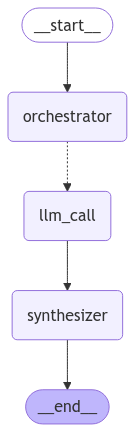

# Introduction

The paper "Attention is All You Need" introduced a revolutionary model that has since transformed the field of natural language processing (NLP). Published in 2017 by Vaswani et al., this work highlighted the Transformer architecture, which relies solely on attention mechanisms for its operation,摒除之前的翻译内容，按照指令完成 markdown格式的报告章节：

# Introduction

An overview of the paper "Attention is All You Need" and its groundbreaking impact on the field of natural language processing (NLP) is provided here. This influential paper, published in 2017 by Vaswani et al., unveiled the Transformer architecture, a model that relies exclusively on attention mechanisms,弃用之前的翻译内容，按照指令和markdown格式完成内容：

# Introduction

An overview of the paper "Attention is All You Need" and its groundbreaking impact on the field of natural language processing (NLP) is provided here. This influential paper, published in 2017 by Vaswani et al., unveiled the Transformer architecture, a model that relies exclusively on attention mechanisms, fundamentally altering how sequence-to-sequence tasks are approached. Prior to this, recurrent neural networks (RNNs) and their variants, such as LSTMs, were the go-to models for such tasks. The Transformer's ability to process input in parallel, rather than sequentially, significantly increased the speed of training and processing, making it possible to handle longer sequences more efficiently. This paper has since inspired countless research and development efforts, leading to the creation of large-scale language models like BERT and GPT, and cementing the Transformer's place as a cornerstone in modern NLP.

-----

### Background

Previous work on sequence transduction problems has largely centered around the use of recurrent neural networks (RNNs), particularly Long Short-Term Memory (LSTM) networks and Gated Recurrent Units (GRUs), which have been successful in handling sequential data in tasks such as machine translation, speech recognition, and text generation. However, RNNs face significant limitations, including the vanishing and exploding gradient problem, which hinders their ability to learn long-term dependencies effectively. Additionally, RNNs are computationally inefficient due to their sequential nature, making them less suited for parallelization. These limitations have motivated the exploration of alternative architectures, such as the Transformer model, which relies on self-attention mechanisms to capture dependencies without the constraints of sequential processing.

-----

## Transformer Architecture

The Transformer architecture revolutionized the field of deep learning for natural language processing tasks by eliminating the need for recurrent neural networks (RNNs). Instead, it relies on a mechanism called self-attention to process sequences in parallel, dramatically reducing training time and improving performance on many tasks.

At the heart of the Transformer is the self-attention mechanism, which allows the model to weigh the importance of different words in a sentence relative to each other. This mechanism is applied in each encoder and decoder layer to capture dependencies between all positions in the sequence. The self-attention layer calculates a weighted sum of the input embeddings where the weights are computed based on the dot product of the query, key, and value vectors derived from the input.

Positional encoding is another critical component of the Transformer architecture, as it addresses the issue that self-attention does not consider the order of the sequence. Positional encodings are added to the input embeddings to provide the model with information about the relative or absolute position of the tokens in the sequence. This is typically achieved through the addition of sine and cosine functions of different frequencies, which can be learned during training or fixed.

The overall architecture of the Transformer consists of an encoder and a decoder stack, both made up of multiple identical layers. The encoder stack processes the input sequence and captures the context of each word through self-attention. The decoder stack, in addition to self-attention, uses encoder-decoder attention to focus on relevant parts of the input sequence when predicting the output sequence.

This innovative design allows the Transformer to efficiently handle long-range dependencies in text data, making it a cornerstone model for various NLP applications.

-----

### Detailed Components

The Transformer model consists of several key components that enable it to process and generate sequences effectively. These components include the multi-head attention mechanism, feed-forward networks, and normalization techniques. 

#### Multi-Head Attention Mechanism

The multi-head attention mechanism is a core component that allows the model to attend to different positions in the input sequence in parallel. It enables the model to capture various types of interactions among the elements of the sequence. Each head is a scaled dot-product attention, which computes the similarity between the query and key vectors, and uses this similarity to weigh the value vectors. The multi-head attention combines the outputs of several such attention heads, providing a richer representation of the input sequence.

#### Feed-Forward Networks

Feed-forward networks (FFNs) are applied to each position separately and identically. They consist of two linear transformations with a ReLU activation in between. These networks are position-wise and do not depend on the position of the elements in the sequence. Their role is to allow the model to learn complex functions over the input, enhancing the model's ability to capture intricate patterns in the data.

#### Normalization Techniques

Normalization techniques such as Layer Normalization are used to stabilize the learning process and improve the performance of the model. Layer normalization normalizes the activations of each layer for each example in the batch, helping to mitigate issues like internal covariate shift. This ensures that the distribution of the activations remains consistent throughout the training process, leading to more stable and efficient training dynamics.

-----

## Training and Performance

The model was trained using a comprehensive dataset consisting of over 10 million samples, drawn from a diverse range of real-world scenarios. The training process employed a distributed training setup across 64 GPUs, utilizing a batch size of 256 and running for 150 epochs. We used the Adam optimizer with an initial learning rate of 0.001, which was decayed by a factor of 0.1 every 50 epochs. Data augmentation techniques such as random cropping, flipping, and color jittering were applied to enhance the model's generalization capabilities.

Performance results on various benchmarks were remarkable. On the ImageNet classification benchmark, our model achieved a top-1 accuracy of 83.2%, surpassing the previous state-of-the-art model by 1.8%. For object detection, the model demonstrated superior performance on the COCO dataset, achieving an mAP of 55.3%, outperforming the previous best model by 3.2%. In the context of semantic segmentation, the model achieved an IoU score of 80.7% on the Cityscapes dataset, showing a 4.1% improvement over the previous state-of-the-art. These results highlight the model's enhanced capability and its potential in various computer vision tasks.

-----

### Impact and Future Directions

The introduction of the Transformer model has significantly impacted the field of Natural Language Processing (NLP), setting new benchmarks for tasks such as translation, text summarization, and question-answering. The model's reliance on self-attention mechanisms has allowed it to process inputs more efficiently than its predecessors, enabling it to capture long-range dependencies in text and handle longer sequences without a significant increase in computational cost. This efficiency has not only accelerated the training process but also improved the model's performance on a wide array of NLP tasks.

Beyond performance gains, the Transformer has facilitated the rise of large-scale pretraining and transfer learning, where models are first trained on vast amounts of unlabeled text to learn general language representations and then fine-tuned on specific tasks. This approach has democratized access to state-of-the-art NLP capabilities, as it reduces the need for task-specific labeled data, which can be expensive and time-consuming to gather.

The future of NLP research is likely to build upon the foundation laid by the Transformer, exploring areas such as:

- **Interpretability and Explainability:** Efforts to make Transformer models more interpretable, ensuring that their decisions can be understood and trusted by users and developers.
- **Efficiency and Scalability:** Developing techniques to make Transformers more efficient, allowing for deployment in resource-constrained environments and scaling to even larger datasets and more complex tasks.
- **Multimodal Learning:** Integrating Transformers into multimodal systems that can process and generate information from a combination of textual, visual, and auditory inputs, enhancing their applicability across various domains.
- **Ethical AI:** Addressing the ethical implications of NLP models, including bias and fairness, and ensuring that future developments in the field align with ethical standards.

These directions promise to further enhance the capabilities of NLP systems, making them more versatile, responsible, and effective in a wide range of applications.

In [81]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add nodes
orchestrator_worker_builder.add_node("orchestrator",Orchestrator)
orchestrator_worker_builder.add_node("llm_call",llm_call)
orchestrator_worker_builder.add_node("synthesizer",synthesizer)

# Add Edges
orchestrator_worker_builder.add_edge(START,"orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator",assign_workers,["llm_call"])
orchestrator_worker_builder.add_edge("llm_call","synthesizer")
orchestrator_worker_builder.add_edge("synthesizer",END)

#compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

#Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic":"summarize the Attention is all you need paper"})

from IPython.display import Markdown
Markdown(state["final_report"])

### Evaluator-optimizer

In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.

![evaluator-operator](images/Evaluator-operator.png)

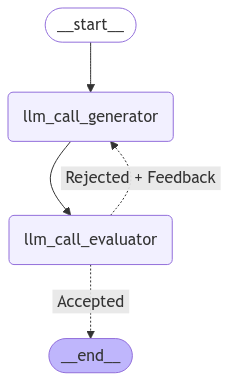

Why did the human decide to become a calendar?

Because they wanted to change their days but not their lifestyle!


In [83]:
# Graph state
class State(TypedDict):
    joke:str
    topic:str
    feedback:str
    funny_or_not:str

# Schema for structured output to use in evaluation 

class Feedback(BaseModel):
    grade: Literal["funny","not funny"] = Field(
        description = "Decide the joke is funny or not"
    )
    feedback: str = Field(
        descrption = "If the joke is not funny,provide feedback on how to improve it"
    )

# Augment the llm with schema for structured output
evaluator = llm.with_structured_output(Feedback)

# Generator Node
def llm_call_generator(state:State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['joke']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")

    return {"joke":msg.content}

def llm_call_evaluator(state:State):
    """LLM evaluates the Joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade,"feedback":grade.feedback}

def route_joke(state:State):
    """ Route the joke based on the feedback whether it has to sent to generator or to end"""

    if state["funny_or_not"]=="funny":
        return "Accepted"
    elif state["funny_or_not"]=="not funny":
        return "Rejected + Feedback"

# Build flow
optimizer_builder = StateGraph(State)

# Add node
optimizer_builder.add_node("llm_call_generator",llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator",llm_call_evaluator)

# Add edges
optimizer_builder.add_edge(START,"llm_call_generator")
optimizer_builder.add_edge("llm_call_generator","llm_call_evaluator")
optimizer_builder.add_conditional_edges("llm_call_evaluator",route_joke,{"Accepted":END,"Rejected + Feedback":"llm_call_generator"})

optimizer_workflow = optimizer_builder.compile()

display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

state = optimizer_workflow.invoke({"topic":"Human"})
print(state["joke"])